이상치 제거 및 섭씨를 화씨로 변환

In [2]:
import pandas as pd

df= pd.read_csv("Final_cleaned_data.csv")
#이상치 제거 대상 리스트
continuous_cols = [
    'travelDurationMinutes',
    'start_humidity',
    'start_windgust',
    'start_windspeed',
    'destin_humidity',
    'destin_windgust',
    'destin_windspeed',
]


# 이상치 제거 방법 : IQR 사분위수
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거 적용
mask = ~((df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)).any(axis=1)
df_cleaned = df[mask].copy()

# 결과 출력
print(f"제거 전 샘플 수: {len(df)}")
print(f"제거 후 샘플 수: {len(df_cleaned)}")
print(f"제거된 샘플 수: {len(df) - len(df_cleaned)}")

#섭씨 온도를 화씨 온도로 변환
df['start_temp'] = df['start_temp'] * 9/5 + 32
df['start_feelslike'] = df['start_feelslike'] * 9/5 + 32

df['destin_temp'] = df['start_temp'] * 9/5 + 32
df['destin_feelslike'] = df['start_feelslike'] * 9/5 + 32

제거 전 샘플 수: 152168
제거 후 샘플 수: 144805
제거된 샘플 수: 7363


baseFare Box-Cox 변환

In [3]:
from scipy.stats import boxcox
import matplotlib.pyplot as plt
import seaborn as sns

# baseFare > 0 필터링
df_boxcox = df_cleaned[df_cleaned['baseFare'] > 0].copy()

# Box-Cox 변환 적용
df_boxcox['boxcox_baseFare'], fitted_lambda = boxcox(df_boxcox['baseFare'])

중복되는 칼럼 제거

In [4]:
drop_cols = ['baseFare', 'boxcox_baseFare', 'log_baseFare', 'fare_per_minute','via_count','daysBeforeFlight']

# 존재하는 컬럼만 제거
existing = [col for col in drop_cols if col in df_boxcox.columns]
X = df_boxcox.drop(columns=existing)

# 종속변수는 제거 전 데이터에서 꺼내야 함
y = df_boxcox['boxcox_baseFare']

print("제거 전 X shape:", df_boxcox.shape)
print("제거 후 X shape:", X.shape)
print("X.columns에 제거 대상 있는지 확인:", set(drop_cols) & set(X.columns))  # 교집합 없어야 정상

제거 전 X shape: (144805, 41)
제거 후 X shape: (144805, 39)
X.columns에 제거 대상 있는지 확인: set()


학습, 테스트, 검증 데이터 분리(7:2:1)

In [5]:
from sklearn.model_selection import train_test_split
# 학습, 테스트, 검증 데이터 분리(7:2:1)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

print(f"\n############데이터 분할 결과#############:")
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")


############데이터 분할 결과#############:
Train: (101363, 39), Valid: (14481, 39), Test: (28961, 39)


In [6]:
# LightGBM 버전 확인
import lightgbm as lgb
print(lgb.__version__)

4.5.0


StandardScaler 적용

In [7]:
from sklearn.preprocessing import StandardScaler
from scipy.special import inv_boxcox
# StandardScaler 를 이용하여 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

Random Search로 최적의 파라미터 찾기

In [8]:
#랜덤 서치로 최적의 파라미터 잡기
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from scipy.special import inv_boxcox
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform
import numpy as np



# RandomizedSearchCV 설정 (LightGBM 용)
base_model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    # n_estimators
    "n_estimators":    [500, 1000, 2000, 3000],
    # learning_rate
    "learning_rate":   [0.03, 0.05, 0.1, 0.2],
    # max_depth
    "max_depth":       [6, 8, 10],
    #reg_lambda
    "reg_lambda":      [1, 3, 5, 7],
    # subsample만 두고 부트스트랩 방식을 LightGBM 기본(bagging_fraction)으로 둠
    "subsample":       [0.6, 0.8, 1.0],
    # colsample_bytree: feature_fraction
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# 평가 지표(RMSE)
rmse_scorer = make_scorer(
    lambda y_true, y_pred: mean_squared_error(y_true, y_pred, squared=False),
    greater_is_better=False
)

random_search = RandomizedSearchCV(
    estimator           = base_model,
    param_distributions = param_dist,
    n_iter              = 5,
    scoring             = rmse_scorer,
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 3
)

# RandomizedSearchCV 실행
random_search.fit(X_train, y_train)

# 최적 모델 추출 및 성능 평가
best_model = random_search.best_estimator_

print("\n 최적 하이퍼파라미터:", random_search.best_params_)


############데이터 분할 결과#############:
Train: (101363, 39), Valid: (14481, 39), Test: (28961, 39)
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4054
[LightGBM] [Info] Number of data points in the train set: 101363, number of used features: 39
[LightGBM] [Info] Start training from score 19.387757

 최적 하이퍼파라미터: {'subsample': 0.8, 'reg_lambda': 7, 'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


최적의 하이퍼파라미터를 반영한 모델 생성

In [9]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_absolute_percentage_error

# 최적의 파라미터를 반영한 버전
params = {
    "n_estimators":      1000,
    "learning_rate":     0.2,
    "max_depth":         10,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_lambda":        7,
    "objective":         "regression",
    "metric":            "rmse",
    "random_state":      42,
    "n_jobs":            -1,
}

model = LGBMRegressor(**params)

# ── 콜백 정의(알 수 없는 이유로 Call Back 적용 - LightGBM 최신 버전 등 할 수 있는 노력 다 했음) ─────────────────────
early_stop = lgb.early_stopping(stopping_rounds=100, verbose=True)
log_eval   = lgb.log_evaluation(period=50)          # 50트리마다 로그

# ── 학습 ────────────────────────────────────────────
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],   # ← 검증 세트를 반드시 넣어야 early stopping 작동
    eval_metric="rmse",
    callbacks=[early_stop, log_eval] # ← early_stop 콜백 전달
)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4054
[LightGBM] [Info] Number of data points in the train set: 101363, number of used features: 39
[LightGBM] [Info] Start training from score 19.387757
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 2.73694
[100]	valid_0's rmse: 2.62824
[150]	valid_0's rmse: 2.57883
[200]	valid_0's rmse: 2.54303
[250]	valid_0's rmse: 2.51888
[300]	valid_0's rmse: 2.49575
[350]	valid_0's rmse: 2.48056
[400]	valid_0's rmse: 2.46185
[450]	valid_0's rmse: 2.45263
[500]	valid_0's rmse: 2.44167
[550]	valid_0's rmse: 2.43079
[600]	valid_0's rmse: 2.42432
[650]	valid_0's rmse: 2.41748
[700]	valid_0's rmse: 2.41497
[750]	valid_0's rmse: 2.40763
[800]	valid_0's rmse: 2.40201
[850]	valid_0's rmse: 2.39813
[900]	valid_0's rmse: 2.3942
[950]	valid_0's rmse: 2.39011
[1000]	valid_0's rmse: 2.3

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.2, max_depth=10,
              metric='rmse', n_estimators=1000, n_jobs=-1,
              objective='regression', random_state=42, reg_lambda=7,
              subsample=0.8)

In [13]:
# Validation 성능 및 Test 성능 평가
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse
import numpy as np
# Validation 성능
y_valid_pred = model.predict(X_valid)
mse_valid = mean_squared_error(y_valid, y_valid_pred)
r2_valid = r2_score(y_valid, y_valid_pred)
print(f"\n--Validation Set 성능(역변환이전)────────────────────────────────────────────")
print(f"MSE: {mse_valid:.4f}")
print(f"R² Score: {r2_valid:.4f}")

# ── 평가 ────────────────────────────────────────────
best_iter = model.best_iteration_
y_test_pred    = model.predict(X_test, num_iteration=best_iter)

mape = mean_absolute_percentage_error(y_test, y_test_pred)
mse_val = mse(y_test, y_test_pred)   # 기본값 squared=True
rmse    = np.sqrt(mse_val)
r2   = r2_score(y_test, y_test_pred)

print(f"\n--Test Set 성능(역변환이전)────────────────────────────────────────────")
print(f"MSE:  {mse_val:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")
print(f"MAPE: {mape*100:.4f}%")


--Validation Set 성능(역변환이전)────────────────────────────────────────────
MSE: 5.6944
R² Score: 0.7617

--Test Set 성능(역변환이전)────────────────────────────────────────────
MSE:  5.9598
RMSE: 2.4413
R^2:  0.7580
MAPE: 10.5495%


In [14]:
#  역변환후

y_test_pred_original = inv_boxcox(y_test_pred, fitted_lambda)
y_test_original = df_boxcox.loc[y_test.index, 'baseFare']
mse_original = mean_squared_error(y_test_original, y_test_pred_original)
r2_original = r2_score(y_test_original, y_test_pred_original)
mae = mean_absolute_error(y_test_original, y_test_pred_original)
medae = median_absolute_error(y_test_original, y_test_pred_original)
mape = mean_absolute_percentage_error(y_test_original, y_test_pred_original)

print(f"\n--Test Set 성능(역변환이후)────────────────────────────────────────────")
print(f"MSE: {mse_original:.2f}")
print(f"R² Score: {r2_original:.2f}")
print(f"MAE: {mae:.2f}")
print(f"Median AE: {medae:.2f}")
print(f"MAPE: {mape*100:.2f}%")


--Test Set 성능(역변환이후)────────────────────────────────────────────
MSE: 11409.31
R² Score: 0.70
MAE: 67.60
Median AE: 47.71
MAPE: 26.00%


In [15]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error



# ── (1) 모델 하이퍼파라미터 정의 ──────────────────────────────────────────────
params = {
    "n_estimators":      1000,
    "learning_rate":     0.2,
    "max_depth":         10,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_lambda":        7,
    "objective":         "regression",
    "metric":            "rmse",
    "random_state":      42,
    "n_jobs":            -1,
}

# ── (2) K-Fold 설정 ───────────────────────────────────────────────────────────
# n_splits : Fold 개수 (여기서는 5번)
# shuffle=True 로 섞고, random_state 고정해서 재현 가능하게 설정
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# ── (43 Fold별 결과를 저장할 리스트 초기화 ────────────────────────────────────
rmse_list = []
r2_list   = []
mae_list  = []

# (필요하다면) OOF(Out-of-Fold) 예측을 기록하고 싶다면 아래 배열 생성
oof_preds = np.zeros(len(X))

# ── (4) K-Fold 반복 ───────────────────────────────────────────────────────────
for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):
    print(f"\n>>> Fold {fold} 학습 시작")

    # train/valid 데이터 분리
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # (a) 모델 초기화
    model = LGBMRegressor(**params)

    # (b) Early Stopping 콜백 정의
    early_stop = lgb.early_stopping(stopping_rounds=100, verbose=False)
    # (원하는 경우) 로그를 보고 싶으면 log_evaluation 추가
    log_eval   = lgb.log_evaluation(period=100, show_stdv=False)

    # (c) 학습(Fit): 검증 세트 지정 및 콜백 전달
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[early_stop, log_eval]
    )

    # (d) 검증 데이터에 대한 예측 및 평가 지표 계산
    y_pred = model.predict(X_valid)
    rmse   = np.sqrt(mean_squared_error(y_valid, y_pred))
    r2     = r2_score(y_valid, y_pred)
    mae    = mean_absolute_error(y_valid, y_pred)

    print(f"Fold {fold} → RMSE: {rmse:.4f}, R2: {r2:.4f}, MAE: {mae:.4f}")

    rmse_list.append(rmse)
    r2_list.append(r2)
    mae_list.append(mae)

    # (e) OOF 예측값 저장 (전체 데이터에 대한 예측 결과 확보 시)
    oof_preds[valid_idx] = y_pred

# ── (5) 전체 Fold 평균 성능 출력 ───────────────────────────────────────────────
print("\n===== K-Fold 교차검증 결과 =====")
print(f"Average RMSE : {np.mean(rmse_list):.4f}  ±  {np.std(rmse_list):.4f}")
print(f"Average R2   : {np.mean(r2_list):.4f}  ±  {np.std(r2_list):.4f}")
print(f"Average MAE  : {np.mean(mae_list):.4f}  ±  {np.std(mae_list):.4f}")


>>> Fold 1 학습 시작
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4051
[LightGBM] [Info] Number of data points in the train set: 115844, number of used features: 39
[LightGBM] [Info] Start training from score 19.381353
[100]	valid_0's rmse: 2.66859
[200]	valid_0's rmse: 2.57929
[300]	valid_0's rmse: 2.52989
[400]	valid_0's rmse: 2.5035
[500]	valid_0's rmse: 2.48774
[600]	valid_0's rmse: 2.4695
[700]	valid_0's rmse: 2.45806
[800]	valid_0's rmse: 2.44825
[900]	valid_0's rmse: 2.43963
[1000]	valid_0's rmse: 2.43224
Fold 1 → RMSE: 2.4322, R2: 0.7598, MAE: 1.7997

>>> Fold 2 학습 시작
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4049
[LightGBM] [In

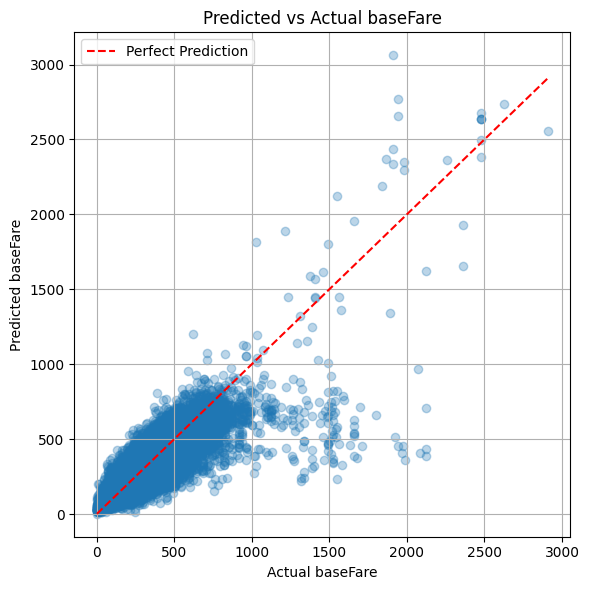

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_original, y_test_pred_original, alpha=0.3)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', label='Perfect Prediction')

plt.xlabel('Actual baseFare')
plt.ylabel('Predicted baseFare')
plt.title('Predicted vs Actual baseFare')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

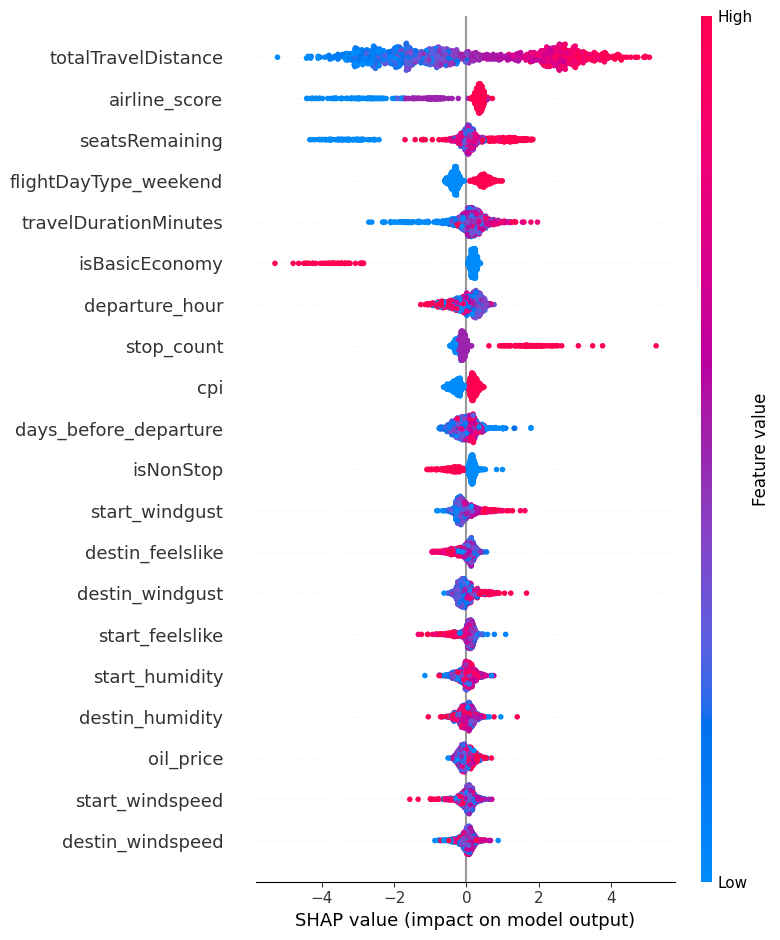

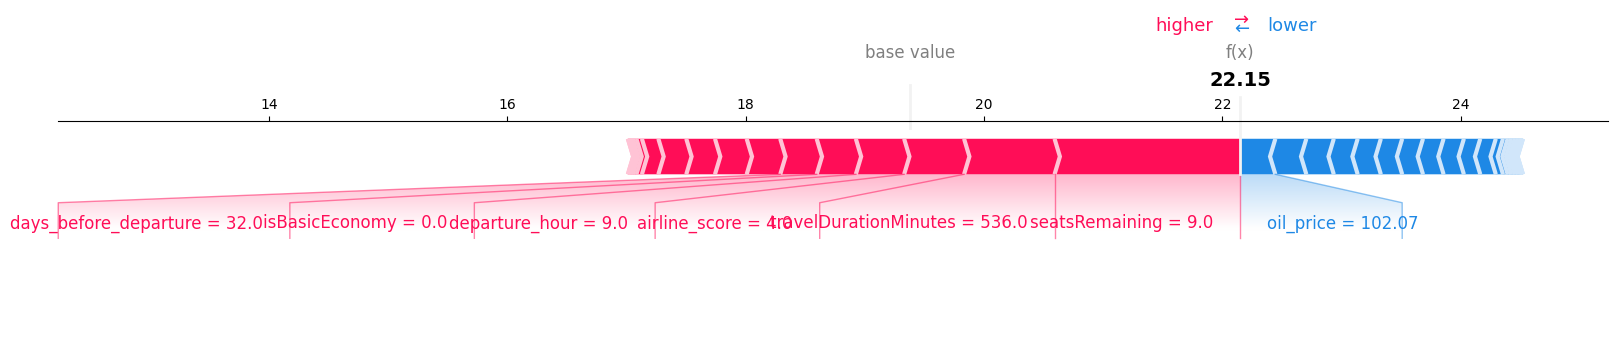

In [17]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt

# SHAP explainer 생성
explainer = shap.TreeExplainer(model)

# 계산 시간 단축을 위해 1000개 샘플만 사용
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# SHAP 요약 플롯
shap.summary_plot(shap_values, X_sample, feature_names=X.columns)

# SHAP Force Plot (개별 예측 설명)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_sample.iloc[0], matplotlib=True)

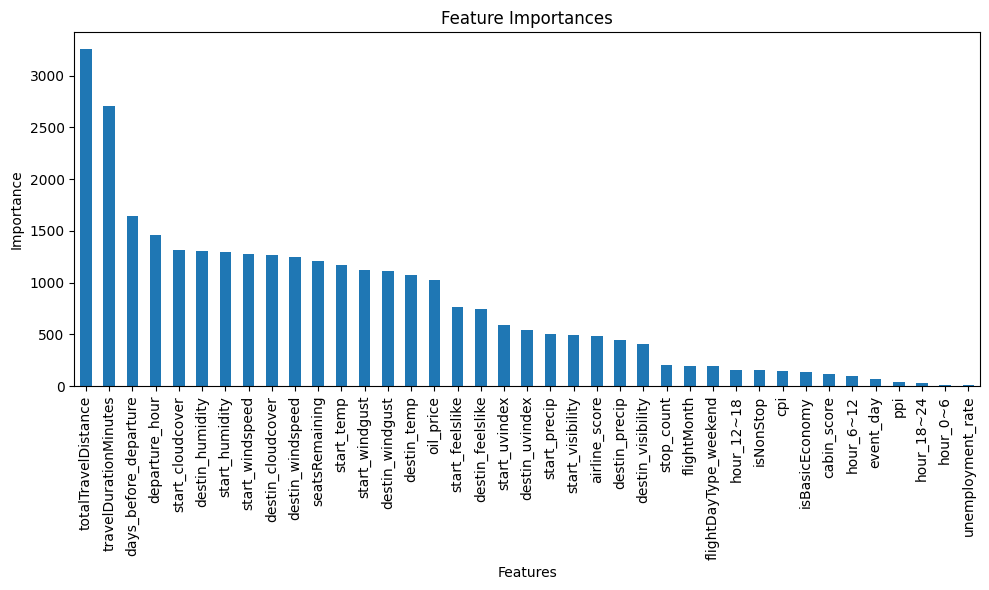

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Feature importance 배열 가져오기
importances = model.feature_importances_
features = X_train.columns  # 학습에 사용한 DataFrame의 컬럼명

# 2) Pandas Series로 변환해서 정렬
fi_series = pd.Series(importances, index=features).sort_values(ascending=False)

# 3) 막대그래프로 시각화
plt.figure(figsize=(10, 6))
fi_series.plot(kind="bar")
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()
